In [24]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

# Resolve project root dynamically
            import json
            prediction_rows = []
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

warnings.filterwarnings('ignore')

import importlib
import torch
import gpytorch
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

import src.models.dkl_autoencoder_svgp as dkl_autoencoder_svgp
import src.models.train_dkl_svgp as train_dkl_svgp
importlib.reload(dkl_autoencoder_svgp)
importlib.reload(train_dkl_svgp)

from src.data.data_loader import load_cmapss_data, StreamingCMAPSSDataset
from src.models.train_dkl_svgp import train_dkl_autoencoder

from src.data.data_loader import load_cmapss_data
from src.models.train_svgp import train_svgp

IndentationError: unexpected indent (526277110.py, line 9)

In [ ]:
from torch.utils.data import TensorDataset

In [ ]:
# 1. Define paths and features 
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

# --- THE FIX: DROP CONSTANT SENSORS ---
# Rimuoviamo i sensori identificati nella EDA per sbloccare i gradienti del kernel
dead_sensors = ['s_1', 's_10', 's_18', 's_19']
features = [f's_{i}' for i in range(1, 22) if f's_{i}' not in dead_sensors]
num_features = len(features)
print(f"Using {num_features} informative features.")

# 2. Load Data
df_train = load_cmapss_data(str(DATA_DIR / 'train_FD001.txt'))
df_test = load_cmapss_data(str(DATA_DIR / 'test_FD001.txt'), str(DATA_DIR / 'RUL_FD001.txt'))

# Piecewise Linear RUL Clipping
MAX_RUL = 125
df_train['RUL'] = df_train['RUL'].clip(upper=MAX_RUL)
df_test['RUL'] = df_test['RUL'].clip(upper=MAX_RUL)

# 3. Strict Normalization for FEATURES (X)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(df_train[features].values)

# 4. Strict Normalization for TARGET (y)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(df_train['RUL'].values.reshape(-1, 1)).flatten()

# 5. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

# 6. Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

Using 17 informative features.


In [ ]:
# Execute the SVGP training loop
# We use 100 inducing points to compress the dataset representation
model, likelihood = train_svgp(
    train_loader=train_loader, 
    num_features=num_features, 
    num_inducing=256, 
    epochs=100, 
    lr=0.01
)

--- Starting SVGP Training (100 Epochs) ---
Epoch 01/100 - Loss (Negative Log Likelihood): 216.1276
Epoch 02/100 - Loss (Negative Log Likelihood): 182.1008
Epoch 03/100 - Loss (Negative Log Likelihood): 169.4155
Epoch 04/100 - Loss (Negative Log Likelihood): 164.5612
Epoch 05/100 - Loss (Negative Log Likelihood): 160.3218
Epoch 06/100 - Loss (Negative Log Likelihood): 158.6611
Epoch 07/100 - Loss (Negative Log Likelihood): 155.5690
Epoch 08/100 - Loss (Negative Log Likelihood): 153.2524
Epoch 09/100 - Loss (Negative Log Likelihood): 150.4639
Epoch 10/100 - Loss (Negative Log Likelihood): 149.3630
Epoch 11/100 - Loss (Negative Log Likelihood): 147.4972
Epoch 12/100 - Loss (Negative Log Likelihood): 147.2805
Epoch 13/100 - Loss (Negative Log Likelihood): 145.8331
Epoch 14/100 - Loss (Negative Log Likelihood): 145.4224
Epoch 15/100 - Loss (Negative Log Likelihood): 144.6539
Epoch 16/100 - Loss (Negative Log Likelihood): 143.9618
Epoch 17/100 - Loss (Negative Log Likelihood): 143.8698
Epoc

In [ ]:
import matplotlib.pyplot as plt

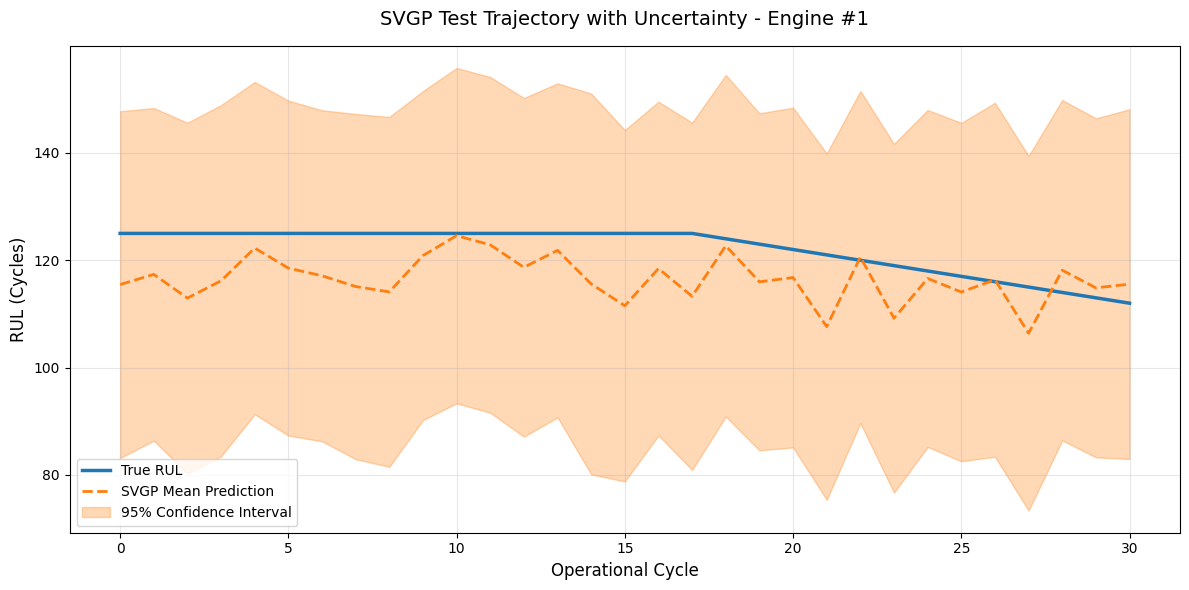

In [ ]:
def plot_svgp_predictions_corrected(engine_id=1):
    model.eval()
    likelihood.eval()

    # Extract test data
    engine_data = df_test[df_test['unit_nr'] == engine_id]
    
    # Scale X using the X scaler
    X_test_scaled = scaler_x.transform(engine_data[features].values)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_true = engine_data['RUL'].values

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(X_test_tensor))
        
        # Extract mean and bounds in SCALED format
        mean_scaled = observed_pred.mean.numpy()
        lower_scaled, upper_scaled = observed_pred.confidence_region()
        lower_scaled = lower_scaled.numpy()
        upper_scaled = upper_scaled.numpy()

    # INVERSE TRANSFORM to get back to original RUL cycles
    mean = scaler_y.inverse_transform(mean_scaled.reshape(-1, 1)).flatten()
    lower = scaler_y.inverse_transform(lower_scaled.reshape(-1, 1)).flatten()
    upper = scaler_y.inverse_transform(upper_scaled.reshape(-1, 1)).flatten()

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label="True RUL", color='#1f77b4', linewidth=2.5)
    
    # SVGP Mean and Uncertainty Bands
    plt.plot(mean, label="SVGP Mean Prediction", color='#ff7f0e', linestyle='--', linewidth=2)
    plt.fill_between(range(len(mean)), lower, upper, alpha=0.3, color='#ff7f0e', label="95% Confidence Interval")

    plt.title(f"SVGP Test Trajectory with Uncertainty - Engine #{engine_id}", fontsize=14, pad=15)
    plt.xlabel("Operational Cycle", fontsize=12)
    plt.ylabel("RUL (Cycles)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_svgp_predictions_corrected(engine_id=1)

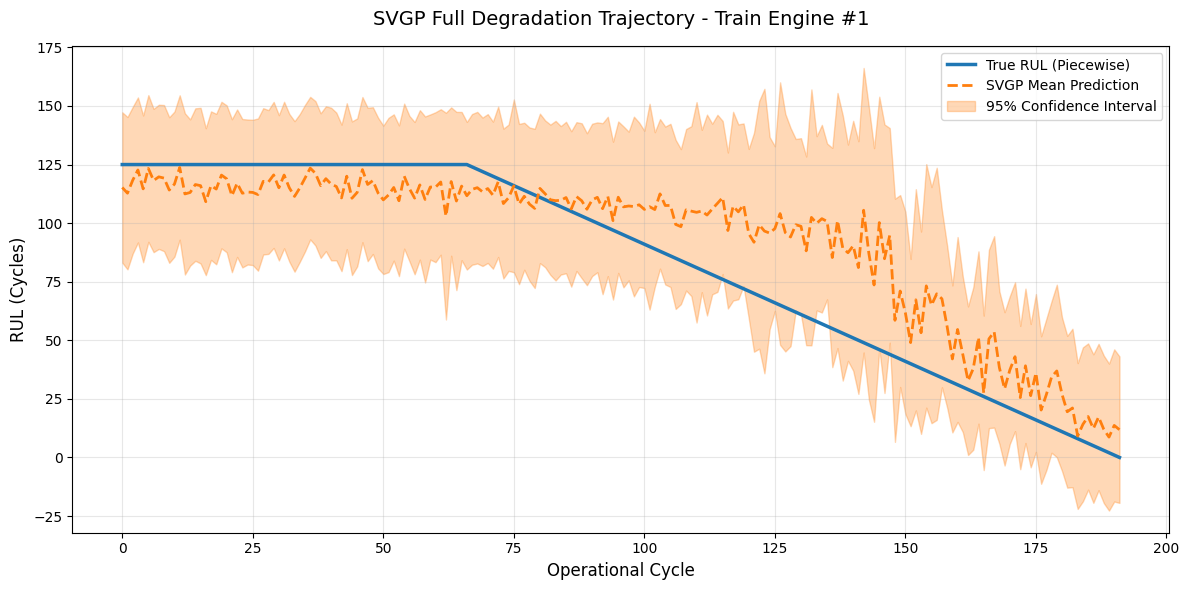

In [ ]:
def plot_svgp_full_degradation(engine_id=1):
    model.eval()
    likelihood.eval()

    # Engine data from TRAIN SET to see the full degradation trajectory
    engine_data = df_train[df_train['unit_nr'] == engine_id]
    
    # Scale X using the X scaler
    X_scaled = scaler_x.transform(engine_data[features].values)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_true = engine_data['RUL'].values

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(X_tensor))
        
        # Extract mean and bounds in SCALED format
        mean_scaled = observed_pred.mean.numpy()
        lower_scaled, upper_scaled = observed_pred.confidence_region()
        
    # INVERSE TRANSFORM to get back to original RUL cycles
    mean = scaler_y.inverse_transform(mean_scaled.reshape(-1, 1)).flatten()
    lower = scaler_y.inverse_transform(lower_scaled.reshape(-1, 1)).flatten()
    upper = scaler_y.inverse_transform(upper_scaled.reshape(-1, 1)).flatten()

    # Plotting
    plt.figure(figsize=(12, 6))
    
    # True RUL (clipped at 125)
    plt.plot(y_true, label="True RUL (Piecewise)", color='#1f77b4', linewidth=2.5)
    
    # SVGP Prediction
    plt.plot(mean, label="SVGP Mean Prediction", color='#ff7f0e', linestyle='--', linewidth=2)
    plt.fill_between(range(len(mean)), lower, upper, alpha=0.3, color='#ff7f0e', label="95% Confidence Interval")

    plt.title(f"SVGP Full Degradation Trajectory - Train Engine #{engine_id}", fontsize=14, pad=15)
    plt.xlabel("Operational Cycle", fontsize=12)
    plt.ylabel("RUL (Cycles)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot on engine 1 to see the full degradation trajectory
plot_svgp_full_degradation(engine_id=1)

In [ ]:
import json
from pathlib import Path

from src.utils.metrics import evaluate_model_on_loader

RESULTS_FILE = PROJECT_ROOT / 'outputs' / '02_svgp_poc_metrics.json'
RESULTS_FILE.parent.mkdir(parents=True, exist_ok=True)

svgp_train_report = evaluate_model_on_loader(model, train_loader, likelihood=likelihood)

X_test_scaled = scaler_x.transform(df_test[features].values)
y_test_scaled = scaler_y.transform(df_test[['RUL']].values)
test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test_scaled, dtype=torch.float32),
)
svgp_test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
svgp_test_report = evaluate_model_on_loader(model, svgp_test_loader, likelihood=likelihood)

if RESULTS_FILE.exists():
    with RESULTS_FILE.open('r', encoding='utf-8') as file_handle:
        all_results = json.load(file_handle)
else:
    all_results = {}

all_results['svgp'] = {
    'train': svgp_train_report,
    'test': svgp_test_report,
}

with RESULTS_FILE.open('w', encoding='utf-8') as file_handle:
    json.dump(all_results, file_handle, indent=2)

print(f'Saved SVGP metrics and results to {RESULTS_FILE}')

Saved SVGP metrics and results to /home/emma/ProbML/PML_Final_Project/outputs/02_svgp_poc_metrics.json


# SVGP + DKL


In [ ]:
import sys
import warnings
from pathlib import Path

# Resolve project root dynamically
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.data_loader import load_cmapss_data
from src.models.train_dkl_svgp import train_dkl_autoencoder

In [ ]:
import sys
import warnings
from pathlib import Path

# Resolve project root dynamically
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

warnings.filterwarnings('ignore')

import torch
import gpytorch
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

from src.data.data_loader import load_cmapss_data, StreamingCMAPSSDataset
from src.models.train_dkl_svgp import train_dkl_autoencoder

# ==========================================
# 1. PREPARAZIONE DATI E DATALOADER
# ==========================================
# Percorsi ai file raw (basato sulla struttura del tuo progetto)
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
TRAIN_FILE = str(DATA_DIR / 'train_FD001.txt')
TEST_FILE = str(DATA_DIR / 'test_FD001.txt')
RUL_FILE = str(DATA_DIR / 'RUL_FD001.txt')

# Sensori attivi (14 feature) tipicamente usati per FD001 (scartati i costanti: 1, 5, 6, 10, 16, 18, 19)
ACTIVE_FEATURES = [
    's_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
    's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21'
]
INPUT_DIM = len(ACTIVE_FEATURES)  # Dovrebbe essere 14
BATCH_SIZE = 256 # Dimensione del batch per il training

print("Caricamento e preprocessing dei dati...")
# Caricamento DataFrame con clipping RUL a 125

df_train = load_cmapss_data(TRAIN_FILE)
df_test = load_cmapss_data(TEST_FILE, RUL_FILE)

# Inizializza lo scaler
scaler = StandardScaler()

# Creazione Dataset (fit_scaler=True SOLO per il train set per evitare data leakage)
train_dataset = StreamingCMAPSSDataset(df_train, features=ACTIVE_FEATURES, scaler=scaler, fit_scaler=True)
test_dataset = StreamingCMAPSSDataset(df_test, features=ACTIVE_FEATURES, scaler=scaler, fit_scaler=False)

# Creazione DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dimensione Train: {len(train_dataset)} campioni | Dimensione Test: {len(test_dataset)} campioni")


# ==========================================
# 2. CONFIGURAZIONE E TRAINING DKL SVGP
# ==========================================
LATENT_DIM = 4   # Bottleneck dell'autoencoder
NUM_INDUCING = 100
EPOCHS = 20
LEARNING_RATE = 0.01
LAMBDA_RECON = 0.5  # Peso per bilanciare loss del GP e loss dell'Autoencoder

print("\nAvvio il training del DKL Autoencoder SVGP...")
model, likelihood = train_dkl_autoencoder(
    train_loader=train_loader,
    input_dim=INPUT_DIM,
    latent_dim=LATENT_DIM,
    num_inducing=NUM_INDUCING,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    lambda_recon=LAMBDA_RECON
)


# ==========================================
# 3. VALUTAZIONE POST-TRAINING (INFERENZA)
# ==========================================
# Mettiamo il modello e la likelihood in modalità eval
print("\n--- Valutazione con ID Motore ---")
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
            prediction_rows = []
            # Iteriamo su tutto il test set 
            for test_x, test_y, unit_nrs in test_loader:
                
                # Predizione
                observed_pred = likelihood(model(test_x))
                pred_mean = observed_pred.mean
                lower, upper = observed_pred.confidence_region()
                
                # Stampa
                for i in range(len(test_x)):
                    u_id = unit_nrs[i].item()
                    y_true = test_y[i].item() if test_y.dim() == 1 else test_y[i][0].item()
                    y_pred = pred_mean[i].item()
                    y_lower = lower[i].item()
                    y_upper = upper[i].item()
                    
                    print(f"Motore: {u_id:03d} | Reale: {y_true:5.1f} | Predetto: {y_pred:5.1f} | "
                          f"Confidenza: [{y_lower:5.1f}, {y_upper:5.1f}]")
                    prediction_rows.append({
                        'unit_nr': int(u_id),
                        'true_rul': float(y_true),
                        'predicted_rul': float(y_pred),
                        'lower_rul': float(y_lower),
                        'upper_rul': float(y_upper)
                    })
            
            from src.utils.metrics import evaluate_prognostics_model
            dkl_report = evaluate_prognostics_model(
                [row['predicted_rul'] for row in prediction_rows],
                [row['true_rul'] for row in prediction_rows],
            )
            
            DETAILED_RESULTS_FILE = PROJECT_ROOT / 'outputs' / '02_svgp_poc_dkl_predictions.json'
            DETAILED_RESULTS_FILE.parent.mkdir(parents=True, exist_ok=True)
            
            with DETAILED_RESULTS_FILE.open('w', encoding='utf-8') as file_handle:
                json.dump({
                    'engine_predictions': prediction_rows,
                    'summary_report': dkl_report,
                }, file_handle, indent=2)
            
            print(f"Saved detailed DKL predictions to {DETAILED_RESULTS_FILE}")

            




     
     

Caricamento e preprocessing dei dati...
Dimensione Train: 20631 campioni | Dimensione Test: 13096 campioni

Avvio il training del DKL Autoencoder SVGP...
--- Starting DKL Autoencoder SVGP Training (20 Epochs) ---
Epoch 01 | MLL Loss: 18592.7315 | Recon Loss: 0.2880
Epoch 02 | MLL Loss: 4006.4590 | Recon Loss: 0.2671
Epoch 03 | MLL Loss: 2677.3894 | Recon Loss: 0.2776
Epoch 04 | MLL Loss: 2119.5689 | Recon Loss: 0.2851
Epoch 05 | MLL Loss: 1809.6943 | Recon Loss: 0.2872
Epoch 06 | MLL Loss: 1617.2657 | Recon Loss: 0.2894
Epoch 07 | MLL Loss: 1495.8545 | Recon Loss: 0.2824
Epoch 08 | MLL Loss: 1392.9562 | Recon Loss: 0.2842
Epoch 09 | MLL Loss: 1326.7094 | Recon Loss: 0.2803
Epoch 10 | MLL Loss: 1272.9777 | Recon Loss: 0.2809
Epoch 11 | MLL Loss: 1237.0365 | Recon Loss: 0.2851
Epoch 12 | MLL Loss: 1203.2381 | Recon Loss: 0.2871
Epoch 13 | MLL Loss: 1179.6438 | Recon Loss: 0.2901
Epoch 14 | MLL Loss: 1160.8727 | Recon Loss: 0.2872
Epoch 15 | MLL Loss: 1144.2431 | Recon Loss: 0.2885
Epoch 

In [ ]:
import json
from pathlib import Path

from src.utils.metrics import evaluate_model_on_loader

RESULTS_FILE = PROJECT_ROOT / 'outputs' / '02_svgp_poc_metrics.json'
RESULTS_FILE.parent.mkdir(parents=True, exist_ok=True)

dkl_train_report = evaluate_model_on_loader(model, train_loader, likelihood=likelihood)
dkl_test_report = evaluate_model_on_loader(model, test_loader, likelihood=likelihood)

if RESULTS_FILE.exists():
    with RESULTS_FILE.open('r', encoding='utf-8') as file_handle:
        all_results = json.load(file_handle)
else:
    all_results = {}

all_results['dkl_autoencoder'] = {
    'train': dkl_train_report,
    'test': dkl_test_report,
}

with RESULTS_FILE.open('w', encoding='utf-8') as file_handle:
    json.dump(all_results, file_handle, indent=2)

print(f'Saved DKL metrics and results to {RESULTS_FILE}')

Saved DKL metrics and results to /home/emma/ProbML/PML_Final_Project/outputs/02_svgp_poc_metrics.json
